# NFL Spread Market Efficiency Analysis

**Dataset:** [NFL Scores and Betting Data – Kaggle](https://www.kaggle.com/datasets/tobycrabtree/nfl-scores-and-betting-data)

## 1. Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 50)

df = pd.read_csv('spreadspoke_scores.csv')
print(df.shape)
df.head()

(14371, 17)


,schedule_date,schedule_season,schedule_week,schedule_playoff,team_home,score_home,score_away,team_away,team_favorite_id,spread_favorite,over_under_line,stadium,stadium_neutral,weather_temperature,weather_wind_mph,weather_humidity,weather_detail
0,9/2/1966,1966,1,False,Miami Dolphins,14,23,Oakland Raiders,LVR,-14.0,NaN,Orange Bowl,False,83.0,6.0,71.0,NaN
1,9/3/1966,1966,1,False,Houston Oilers,45,7,Denver Broncos,TEN,-7.0,NaN,Rice Stadium,False,81.0,7.0,70.0,NaN
2,9/4/1966,1966,1,False,San Diego Chargers,27,7,Buffalo Bills,LAC,-4.0,NaN,Balboa Stadium,False,70.0,7.0,82.0,NaN
3,9/9/1966,1966,2,False,Miami Dolphins,14,19,New York Jets,NYJ,-16.0,NaN,Orange Bowl,False,82.0,11.0,78.0,NaN
4,9/10/1966,1966,1,False,Green Bay Packers,24,3,Baltimore Colts,GB,-1.0,NaN,Milwaukee County Stadium,False,64.0,8.0,62.0,NaN


## Data Preparation

In [ ]:
df['schedule_season'].unique()

array([1966, 1967, 1968, 1969, 1970, 1971, 1972, 1973, 1974, 1975, 1976,
       1977, 1978, 1979, 1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987,
       1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998,
       1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009,
       2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020,
       2021, 2022, 2023, 2024, 2025])

In [6]:
missing = df.isnull().sum() / len(df) * 100
missing

schedule_date           0.000000
schedule_season         0.000000
schedule_week           0.000000
schedule_playoff        0.000000
team_home               0.000000
score_home              0.000000
score_away              0.000000
team_away               0.000000
team_favorite_id        0.034792
spread_favorite         0.034792
over_under_line        17.152599
stadium                 0.000000
stadium_neutral         0.000000
weather_temperature    10.507272
weather_wind_mph       10.625565
weather_humidity       39.343122
weather_detail         76.925753
dtype: float64

Weather columns missing a decent amount of data. weather_detail missing almost 77% of data, might be better off without this column.

In [7]:
fake_nulls = ['null', 'Null', 'NULL', 'NaN', 'nan', 'NA', 'na', 'N/A', 'n/a', 'None', 'none', '']
for col in df.select_dtypes(include='object'):
    df[col] = df[col].str.strip().str.lower()
    df[col] = df[col].replace(fake_nulls, pd.NA)


In [8]:
missing = df.isnull().sum() / len(df) * 100
missing

schedule_date           0.000000
schedule_season         0.000000
schedule_week           0.000000
schedule_playoff        0.000000
team_home               0.000000
score_home              0.000000
score_away              0.000000
team_away               0.000000
team_favorite_id        0.034792
spread_favorite         0.034792
over_under_line        17.584023
stadium                 0.000000
stadium_neutral         0.000000
weather_temperature    10.507272
weather_wind_mph       10.625565
weather_humidity       39.343122
weather_detail         76.925753
dtype: float64

This also checked for fake nulls, ended up being same numbers.

In [9]:
df.describe()

,schedule_season,score_home,score_away,spread_favorite,weather_temperature,weather_wind_mph,weather_humidity
count,14371.000000,14371.000000,14371.000000,14366.000000,12861.000000,12844.000000,8717.000000
mean,1997.743859,22.543038,19.881845,-5.767785,59.021071,7.523746,67.036480
std,16.993572,10.507446,10.142325,3.800451,15.618880,5.733891,15.923443
min,1966.000000,0.000000,0.000000,-28.000000,-9.000000,0.000000,4.000000
25%,1984.000000,15.000000,13.000000,-7.500000,48.000000,1.000000,57.000000
50%,1999.000000,22.000000,20.000000,-5.000000,62.000000,8.000000,69.000000
75%,2012.000000,30.000000,27.000000,-3.000000,72.000000,11.000000,79.000000
max,2025.000000,72.000000,62.000000,0.000000,97.000000,40.000000,100.000000


array([[<Axes: title={'center': 'score_home'}>,
        <Axes: title={'center': 'score_away'}>],
       [<Axes: title={'center': 'spread_favorite'}>,
        <Axes: title={'center': 'weather_temperature'}>],
       [<Axes: title={'center': 'weather_humidity'}>,
        <Axes: title={'center': 'weather_wind_mph'}>]], dtype=object)

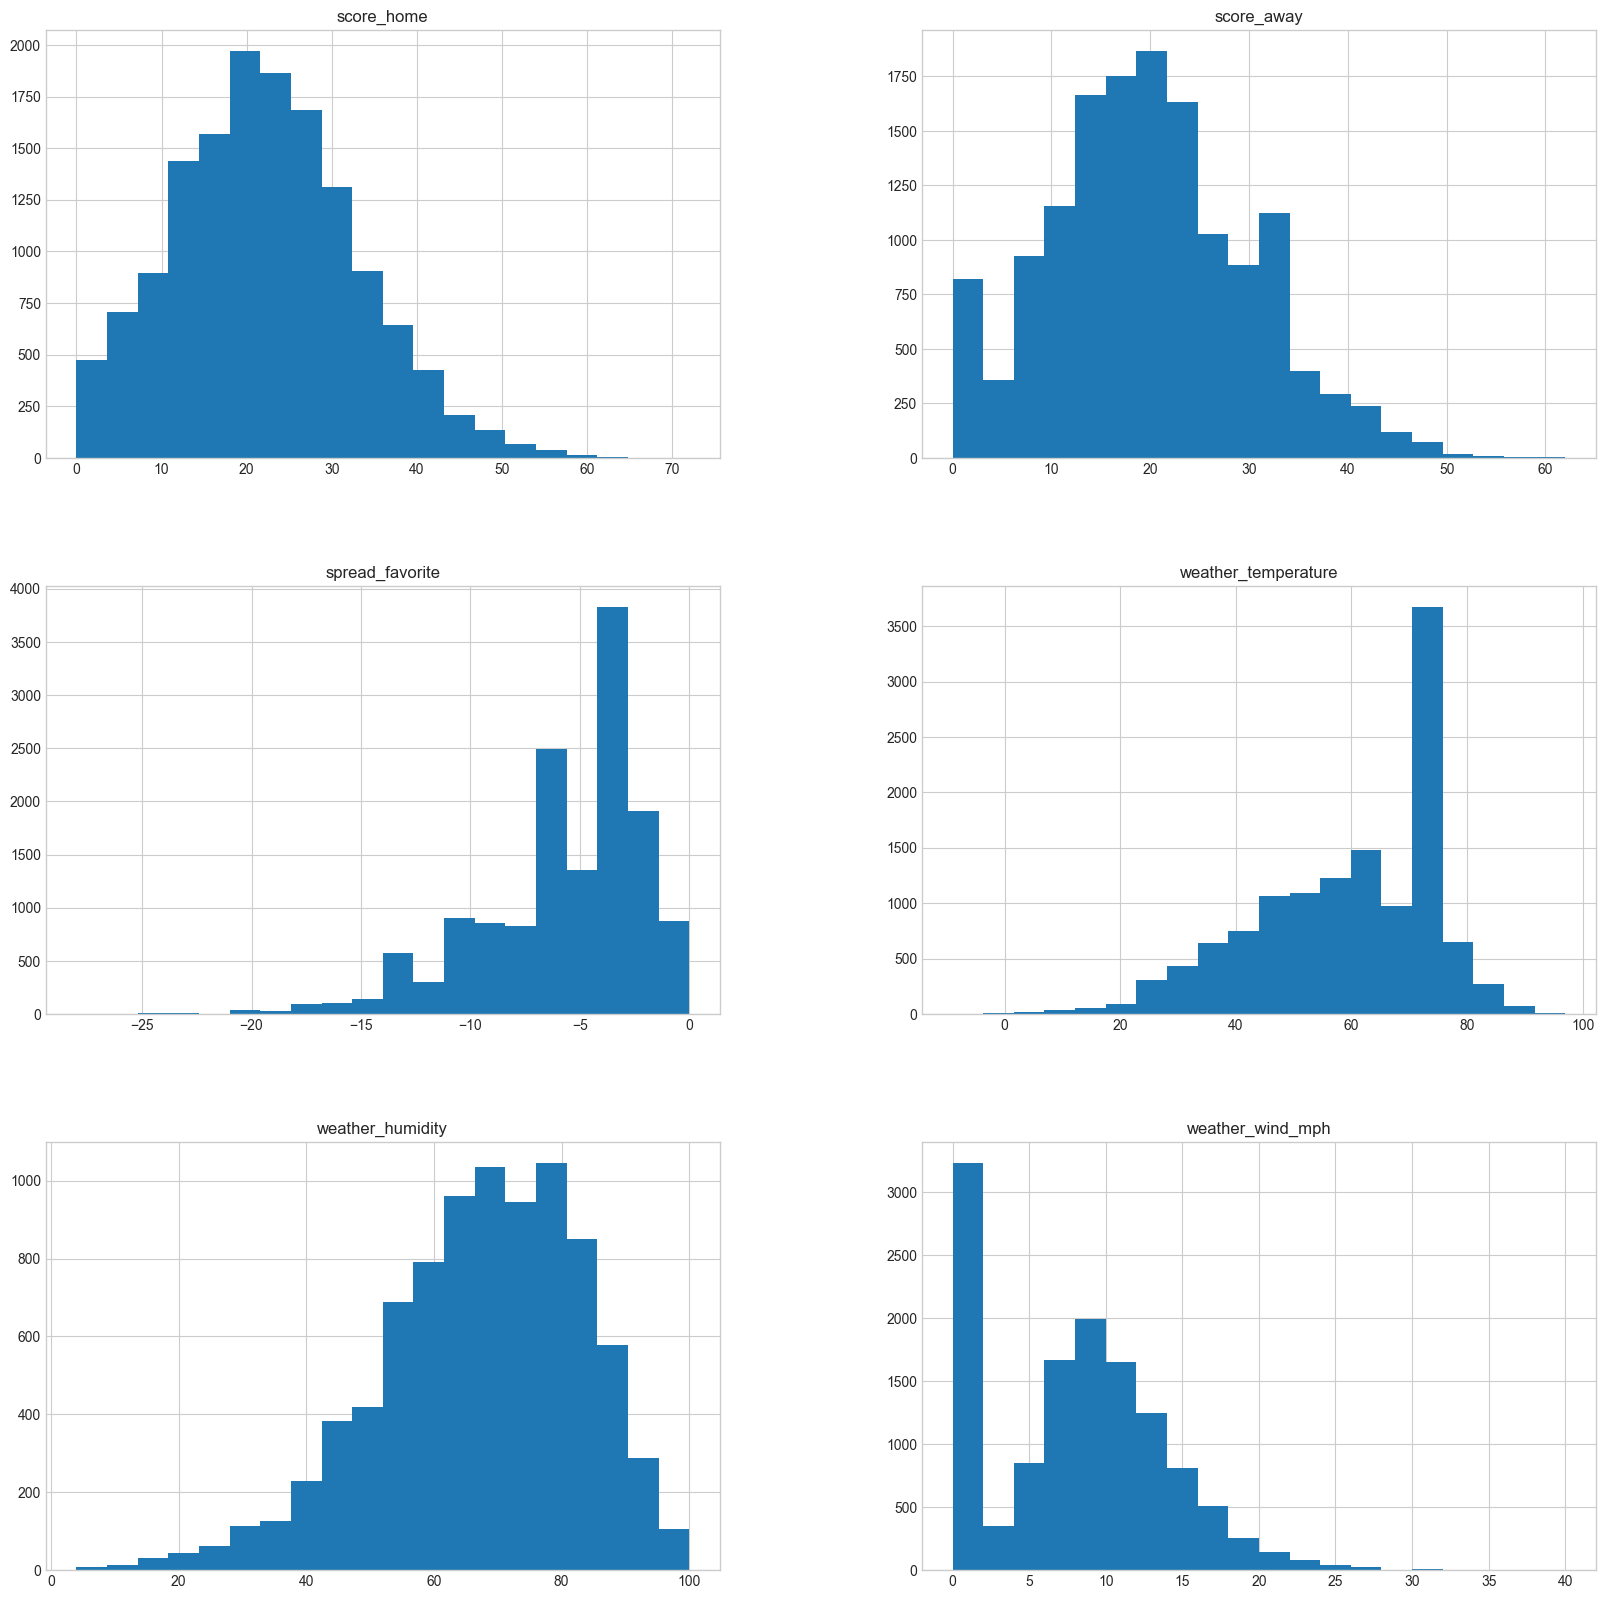

In [18]:
df[['score_home', 'score_away', 'spread_favorite', 'weather_temperature', 'weather_humidity', 'weather_wind_mph']].hist(figsize=(20,20), bins=20)

In [19]:
# Filter to just look at modern era data (2000+)
df_modern = df[df['schedule_season'] >= 2000]

In [20]:
# size of modern era dataset
print(df_modern.shape)

(7017, 17)


In [25]:
# check for duplicates
print(df_modern.duplicated().sum())

0


In [21]:
# Drow rows where spread_favorite and over_under_line is null
df_modern = df_modern.dropna(subset=['spread_favorite', 'over_under_line'])

In [24]:
# parse date column
df_modern['schedule_date'] = pd.to_datetime(df_modern['schedule_date'])
df_modern['schedule_month'] = df_modern['schedule_date'].dt.month
df_modern['schedule_day'] = df_modern['schedule_date'].dt.day

In [72]:
# schedule_day of week
df_modern['day_of_week'] = df_modern['schedule_date'].dt.day_name()

In [26]:
df_modern.head()

,schedule_date,schedule_season,schedule_week,schedule_playoff,team_home,score_home,score_away,team_away,team_favorite_id,spread_favorite,over_under_line,stadium,stadium_neutral,weather_temperature,weather_wind_mph,weather_humidity,weather_detail,schedule_month,schedule_day
7354,2000-09-03,2000,1,False,atlanta falcons,36,28,san francisco 49ers,atl,-6.5,46.5,georgia dome,False,72.0,0.0,NaN,indoor,9,3
7355,2000-09-03,2000,1,False,buffalo bills,16,13,tennessee titans,buf,-1.0,40,ralph wilson stadium,False,70.0,7.0,82.0,NaN,9,3
7356,2000-09-03,2000,1,False,cleveland browns,7,27,jacksonville jaguars,jax,-10.5,38.5,firstenergy stadium,False,75.0,8.0,86.0,NaN,9,3
7357,2000-09-03,2000,1,False,dallas cowboys,14,41,philadelphia eagles,dal,-6.0,39.5,texas stadium,False,95.0,7.0,32.0,NaN,9,3
7358,2000-09-03,2000,1,False,green bay packers,16,20,new york jets,gb,-2.5,44,lambeau field,False,69.0,13.0,87.0,NaN,9,3


In [ ]:
print(df_modern['team_favorite_id'].unique())

['atl' 'buf' 'jax' 'dal' 'gb' 'ind' 'mia' 'min' 'tb' 'pick' 'nyg' 'lvr'
 'bal' 'was' 'lar' 'ari' 'cin' 'den' 'phi' 'lac' 'car' 'ten' 'nyj' 'chi'
 'pit' 'kc' 'ne' 'sea' 'no' 'det' 'sf' 'cle' 'hou']


In [ ]:
df_modern[df_modern['team_favorite_id'] == 'pick']

,schedule_date,schedule_season,schedule_week,schedule_playoff,team_home,score_home,score_away,team_away,team_favorite_id,spread_favorite,over_under_line,stadium,stadium_neutral,weather_temperature,weather_wind_mph,weather_humidity,weather_detail,schedule_month,schedule_day
7363,2000-09-03,2000,1,False,new orleans saints,10,14,detroit lions,pick,0.0,40.5,louisiana superdome,False,72.0,0.0,NaN,indoor,9,3
7447,2000-10-15,2000,7,False,new orleans saints,24,6,carolina panthers,pick,0.0,40.5,louisiana superdome,False,72.0,0.0,NaN,indoor,10,15
7541,2000-11-27,2000,13,False,carolina panthers,31,14,green bay packers,pick,0.0,44,bank of america stadium,False,47.0,6.0,71.0,NaN,11,27
7543,2000-12-03,2000,14,False,atlanta falcons,10,30,seattle seahawks,pick,0.0,42,georgia dome,False,72.0,0.0,NaN,indoor,12,3
7549,2000-12-03,2000,14,False,new orleans saints,23,38,denver broncos,pick,0.0,45,louisiana superdome,False,72.0,0.0,NaN,indoor,12,3
7615,2001-09-09,2001,1,False,cincinnati bengals,23,17,new england patriots,pick,0.0,36,paul brown stadium,False,75.0,11.0,84.0,NaN,9,9
7675,2001-10-14,2001,5,False,green bay packers,31,23,baltimore ravens,pick,0.0,34,lambeau field,False,53.0,12.0,80.0,NaN,10,14
7765,2001-11-25,2001,11,False,new england patriots,34,17,new orleans saints,pick,0.0,42,foxboro stadium,False,52.0,11.0,86.0,NaN,11,25
7874,2002-09-08,2002,1,False,carolina panthers,10,7,baltimore ravens,pick,0.0,33,bank of america stadium,False,73.0,8.0,66.0,NaN,9,8
7893,2002-09-15,2002,2,False,indianapolis colts,13,21,miami dolphins,pick,0.0,47,rca dome,False,72.0,0.0,NaN,indoor,9,15


These are coinflip games with no favorites. Since there are only 46 of them, let's just drop them since it's statistically meaningless (less than 1% of our data).

In [ ]:
df_modern = df_modern[df_modern['team_favorite_id'] != 'pick']

In [31]:
print(df_modern['team_home'].unique())

['atlanta falcons' 'buffalo bills' 'cleveland browns' 'dallas cowboys'
 'green bay packers' 'kansas city chiefs' 'miami dolphins'
 'minnesota vikings' 'new england patriots' 'new york giants'
 'oakland raiders' 'pittsburgh steelers' 'washington redskins'
 'st. louis rams' 'arizona cardinals' 'baltimore ravens'
 'cincinnati bengals' 'denver broncos' 'detroit lions'
 'indianapolis colts' 'philadelphia eagles' 'san diego chargers'
 'san francisco 49ers' 'seattle seahawks' 'tampa bay buccaneers'
 'tennessee titans' 'new york jets' 'carolina panthers' 'chicago bears'
 'jacksonville jaguars' 'new orleans saints' 'houston texans'
 'los angeles rams' 'los angeles chargers' 'washington football team'
 'las vegas raiders' 'washington commanders']


Need to map the team_favorite_id to the full team name instead of just the 3 letter abbreviation. We have to be careful when doing this because teams changed names or cities based on the era. Ex. Washington [commanders, football team, redskins]

In [38]:
def team_mapping(row):
    abbr = row['team_favorite_id']
    season = row['schedule_season']

    mapping = {
        'atl': 'atlanta falcons',
        'buf': 'buffalo bills',
        'car': 'carolina panthers',
        'chi': 'chicago bears',
        'cin': 'cincinnati bengals',
        'cle': 'cleveland browns',
        'dal': 'dallas cowboys',
        'den': 'denver broncos',
        'det': 'detroit lions',
        'gb': 'green bay packers',
        'hou': 'houston texans',
        'ind': 'indianapolis colts',
        'jax': 'jacksonville jaguars',
        'kc': 'kansas city chiefs',
        'mia': 'miami dolphins',
        'min': 'minnesota vikings',
        'ne': 'new england patriots',
        'no': 'new orleans saints',
        'nyg': 'new york giants',
        'nyj': 'new york jets',
        'phi': 'philadelphia eagles',
        'pit': 'pittsburgh steelers',
        'sea': 'seattle seahawks',
        'sf': 'san francisco 49ers',
        'tb': 'tampa bay buccaneers',
        'ten': 'tennessee titans',
        'bal': 'baltimore ravens',
        'ari':'arizona cardinals',

        'was': 'washington redskins' if season <= 2019
            else ('washington football team' if season <= 2021
                  else 'washington commanders'),

         'sd':  'san diego chargers',
        'lac': 'los angeles chargers' if season >= 2017 else 'san diego chargers',

        'oak': 'oakland raiders',
        'lvr': 'las vegas raiders',

        'stl': 'st. louis rams',
        'lar': 'los angeles rams'
    }
    return mapping.get(abbr, None)

df_modern['fav_fullname'] = df_modern.apply(team_mapping, axis=1)
    

In [39]:
unmapped = df_modern[df_modern['fav_fullname'].isna()]['team_favorite_id'].unique()
print(f"Unmapped abbreviations: {unmapped}")

Unmapped abbreviations: []


In [40]:
# get favorite and underdog scores
df_modern['score_favorite'] = np.where(
    df_modern['fav_fullname'] == df_modern['team_home'],
    df_modern['score_home'], 
    df_modern['score_away']
)

df_modern['score_underdog'] = np.where(
    df_modern['fav_fullname'] == df_modern['team_home'],
    df_modern['score_away'], 
    df_modern['score_home']
)

In [ ]:
# calculate margin and if favorite covered
df_modern['margin'] = df_modern['score_favorite'] - df_modern['score_underdog']
df_modern['favorite_cover'] = (df_modern['margin'] + df_modern['spread_favorite'] > 0).astype(int)

In [42]:
# home team advantage
df_modern['home_favorite'] = (df_modern['fav_fullname'] == df_modern['team_home']).astype(int)

In [43]:
# spread magnitude
df_modern['spread_magnitude'] = df_modern['spread_favorite'].abs()

In [44]:
# playoff game
df_modern['is_playoff'] = df_modern['schedule_playoff'].astype(int)

In [45]:
# total score
df_modern['total_score'] = df_modern['score_home'] + df_modern['score_away']

In [51]:
df_modern['over_under_line'] = pd.to_numeric(df_modern['over_under_line'], errors='coerce')

In [52]:
# game went over line
df_modern['over_line'] = (df_modern['total_score'] > df_modern['over_under_line']).astype(int)

In [ ]:
# checking the new columns
print(df_modern[['team_home', 'fav_fullname', 'home_favorite', 'spread_favorite', 
          'margin', 'favorite_cover']].head(10))
print(f"\nTotal games: {len(df_modern)}")
print(f"Cover rate: {df_modern['favorite_cover'].mean():.3f}")
print(f"Over line rate: {df_modern['over_line'].mean():.3f}")

                 team_home          fav_fullname  home_favorite  \
7354       atlanta falcons       atlanta falcons              1   
7355         buffalo bills         buffalo bills              1   
7356      cleveland browns  jacksonville jaguars              0   
7357        dallas cowboys        dallas cowboys              1   
7358     green bay packers     green bay packers              1   
7359    kansas city chiefs    indianapolis colts              0   
7360        miami dolphins        miami dolphins              1   
7361     minnesota vikings     minnesota vikings              1   
7362  new england patriots  tampa bay buccaneers              0   
7364       new york giants       new york giants              1   

      spread_favorite  margin  favorite_cover  
7354             -6.5       8               1  
7355             -1.0       3               1  
7356            -10.5      20               1  
7357             -6.0     -27               0  
7358             -2.5 

## 3. Exploratory Data Analysis

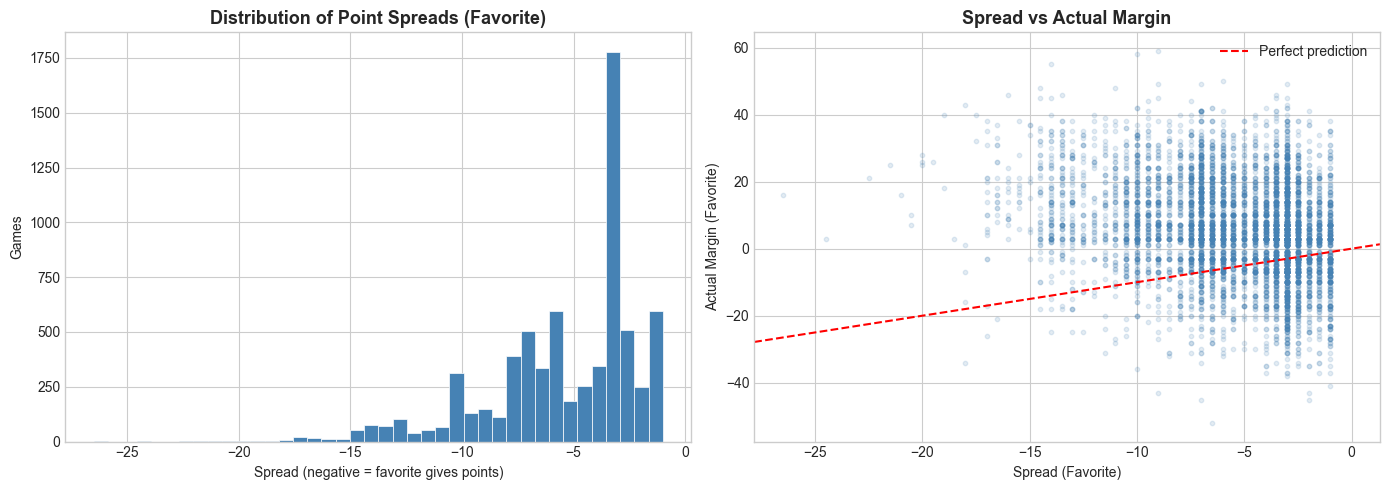

Mean spread: -5.39
Spread std: 3.41


In [60]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Spread distribution
axes[0].hist(df_modern['spread_favorite'], bins=40, color='steelblue', edgecolor='white', linewidth=0.5)
axes[0].set_title('Distribution of Point Spreads (Favorite)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Spread (negative = favorite gives points)')
axes[0].set_ylabel('Games')

# Actual margin vs spread
axes[1].scatter(df_modern['spread_favorite'], df_modern['margin'], alpha=0.15, color='steelblue', s=10)
axes[1].axline((0, 0), slope=1, color='red', linestyle='--', linewidth=1.5, label='Perfect prediction')
axes[1].set_title('Spread vs Actual Margin', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Spread (Favorite)')
axes[1].set_ylabel('Actual Margin (Favorite)')
axes[1].legend()

plt.tight_layout()
plt.savefig('fig1_spread_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Mean spread: {df_modern['spread_favorite'].mean():.2f}")
print(f"Spread std: {df_modern['spread_favorite'].std():.2f}")

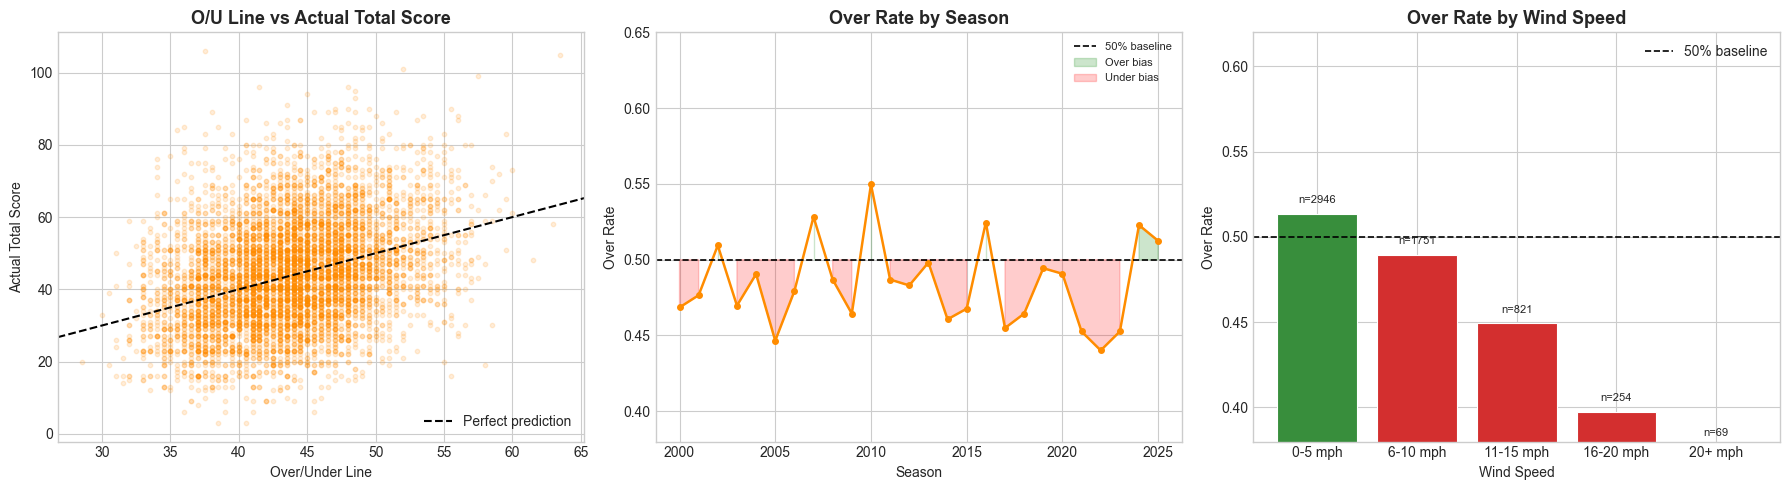

In [65]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Plot 1: Actual Total vs O/U Line ---
axes[0].scatter(df_modern['over_under_line'], df_modern['total_score'], 
                alpha=0.15, color='darkorange', s=10)
axes[0].axline((40, 40), slope=1, color='black', linestyle='--', 
               linewidth=1.5, label='Perfect prediction')
axes[0].set_title('O/U Line vs Actual Total Score', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Over/Under Line')
axes[0].set_ylabel('Actual Total Score')
axes[0].legend()

# --- Plot 2: Over Rate by Season ---
over_by_season = df_modern.groupby('schedule_season')['over_line'].mean().reset_index()
over_by_season.columns = ['season', 'over_rate']

axes[1].plot(over_by_season['season'], over_by_season['over_rate'],
             marker='o', markersize=4, color='darkorange', linewidth=1.8)
axes[1].axhline(0.5, color='black', linestyle='--', linewidth=1.2, label='50% baseline')
axes[1].fill_between(over_by_season['season'], over_by_season['over_rate'], 0.5,
                     where=over_by_season['over_rate'] > 0.5, alpha=0.2, color='green', label='Over bias')
axes[1].fill_between(over_by_season['season'], over_by_season['over_rate'], 0.5,
                     where=over_by_season['over_rate'] < 0.5, alpha=0.2, color='red', label='Under bias')
axes[1].set_title('Over Rate by Season', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Season')
axes[1].set_ylabel('Over Rate')
axes[1].set_ylim(0.38, 0.65)
axes[1].legend(fontsize=8)

# --- Plot 3: Over Rate by Wind Speed ---
# Drop rows missing weather data
weather_df = df_modern.dropna(subset=['weather_wind_mph', 'weather_temperature'])

# Bin wind speed
weather_df = weather_df.copy()
weather_df['wind_bucket'] = pd.cut(weather_df['weather_wind_mph'],
    bins=[-1, 5, 10, 15, 20, 60],
    labels=['0-5 mph', '6-10 mph', '11-15 mph', '16-20 mph', '20+ mph'])

wind_over = weather_df.groupby('wind_bucket', observed=True).agg(
    over_rate=('over_line', 'mean'),
    games=('over_line', 'count')
).reset_index()

bars = axes[2].bar(wind_over['wind_bucket'], wind_over['over_rate'],
                   color=['#d32f2f' if x < 0.5 else '#388e3c' for x in wind_over['over_rate']],
                   edgecolor='white', linewidth=0.8)
axes[2].axhline(0.5, color='black', linestyle='--', linewidth=1.2, label='50% baseline')
axes[2].set_title('Over Rate by Wind Speed', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Wind Speed')
axes[2].set_ylabel('Over Rate')
axes[2].set_ylim(0.38, 0.62)
axes[2].legend()

# Annotate bars with game count
for bar, (_, row) in zip(bars, wind_over.iterrows()):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'n={row["games"]}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('fig_over_under_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Overall cover rate
overall_cover = df_modern['favorite_cover'].mean()
print(f"Overall favorite cover rate: {overall_cover:.3f} ({overall_cover*100:.1f}%)")

# Binomial test: is this significantly different from 50%?
n = len(df_modern['favorite_cover'].dropna())
k = df_modern['favorite_cover'].sum()
binom_result = stats.binomtest(int(k), n, 0.5)
print(f"Binomial test p-value: {binom_result.pvalue:.4f}")
print(f"Interpretation: {'Market is efficient (no significant bias)' if binom_result.pvalue > 0.05 else 'Statistically significant bias detected'}")

Overall favorite cover rate: 0.469 (46.9%)
Binomial test p-value: 0.0000
Interpretation: Statistically significant bias detected


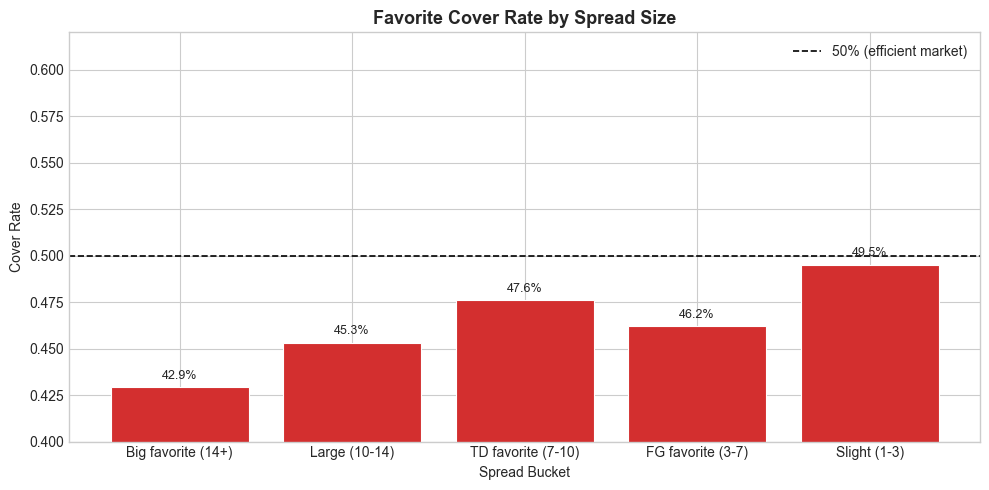

        spread_bucket  games  cover_rate
0  Big favorite (14+)    205    0.429268
1       Large (10-14)    640    0.453125
2  TD favorite (7-10)   1284    0.475857
3   FG favorite (3-7)   3491    0.462045
4        Slight (1-3)   1351    0.495189


In [ ]:
# Cover rate by spread bucket
df_modern['spread_bucket'] = pd.cut(df_modern['spread_favorite'], 
    bins=[-30, -14, -10, -7, -3, -1, 0],
    labels=['Big favorite (14+)', 'Large (10-14)', 'TD favorite (7-10)', 'FG favorite (3-7)', 'Slight (1-3)'])

cover_by_spread = df_modern.groupby('spread_bucket', observed=True).agg(
    games=('favorite_cover', 'count'),
    cover_rate=('favorite_cover', 'mean')
).reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(cover_by_spread['spread_bucket'], cover_by_spread['cover_rate'], 
              color=['#d32f2f' if x < 0.5 else '#388e3c' for x in cover_by_spread['cover_rate']],
              edgecolor='white', linewidth=0.8)
ax.axhline(0.5, color='black', linestyle='--', linewidth=1.2, label='50% (efficient market)')
ax.set_title('Favorite Cover Rate by Spread Size', fontsize=13, fontweight='bold')
ax.set_xlabel('Spread Bucket')
ax.set_ylabel('Cover Rate')
ax.set_ylim(0.4, 0.62)
ax.legend()
for bar, rate in zip(bars, cover_by_spread['cover_rate']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003, 
            f'{rate:.1%}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('fig2_cover_by_spread.png', dpi=150, bbox_inches='tight')
plt.show()
print(cover_by_spread)

In [73]:
# Cover rate: home favorite vs away favorite
home_fav = df_modern[df_modern['home_favorite'] == 1]['favorite_cover'].mean()
away_fav = df_modern[df_modern['home_favorite'] == 0]['favorite_cover'].mean()
print(f"Home favorite cover rate: {home_fav:.3f}")
print(f"Away favorite cover rate: {away_fav:.3f}")

# Cover rate by day of week
cover_by_day = df_modern.groupby('day_of_week')['favorite_cover'].agg(['mean','count'])
cover_by_day.columns = ['cover_rate', 'games']
cover_by_day = cover_by_day[cover_by_day['games'] > 50]  # filter low sample
cover_by_day = cover_by_day.sort_values('cover_rate', ascending=False)
print("\nCover rate by day:")
print(cover_by_day)

Home favorite cover rate: 0.471
Away favorite cover rate: 0.466

Cover rate by day:
             cover_rate  games
day_of_week                   
Thursday       0.506410    312
Monday         0.505470    457
Saturday       0.467742    248
Sunday         0.464739   5913


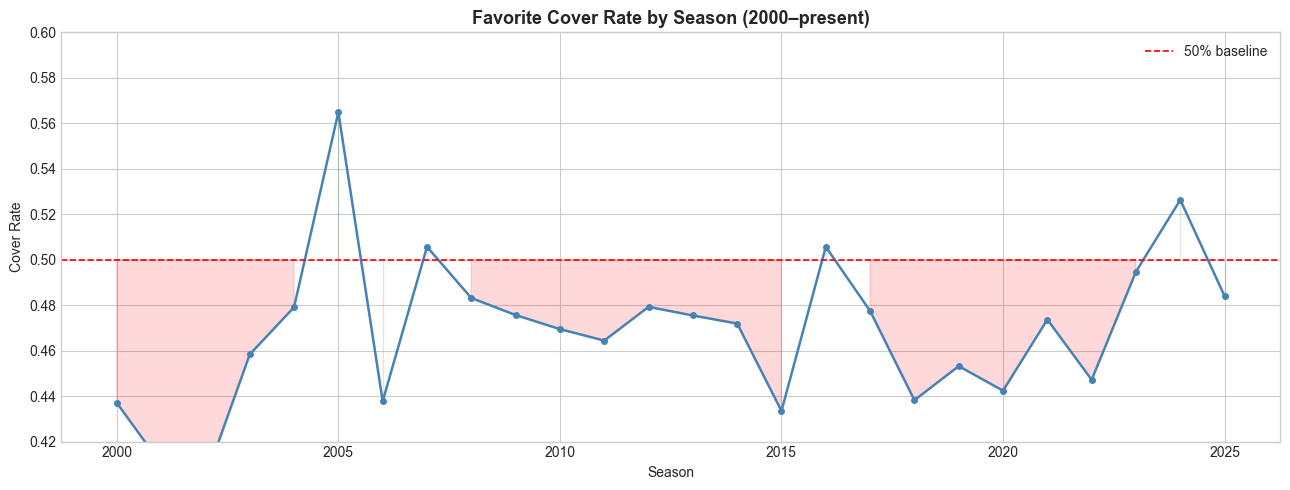

In [74]:
# Cover rate over time (by season) — is the market getting more efficient?
cover_by_season = df_modern.groupby('schedule_season')['favorite_cover'].agg(['mean','count']).reset_index()
cover_by_season.columns = ['season', 'cover_rate', 'games']

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(cover_by_season['season'], cover_by_season['cover_rate'], 
        marker='o', markersize=4, color='steelblue', linewidth=1.8)
ax.axhline(0.5, color='red', linestyle='--', linewidth=1.2, label='50% baseline')
ax.fill_between(cover_by_season['season'], cover_by_season['cover_rate'], 0.5,
                where=cover_by_season['cover_rate'] > 0.5, alpha=0.15, color='green')
ax.fill_between(cover_by_season['season'], cover_by_season['cover_rate'], 0.5,
                where=cover_by_season['cover_rate'] < 0.5, alpha=0.15, color='red')
ax.set_title('Favorite Cover Rate by Season (2000–present)', fontsize=13, fontweight='bold')
ax.set_xlabel('Season')
ax.set_ylabel('Cover Rate')
ax.set_ylim(0.42, 0.60)
ax.legend()
plt.tight_layout()
plt.savefig('fig3_cover_by_season.png', dpi=150, bbox_inches='tight')
plt.show()

Over rate: 0.484 (48.4%)


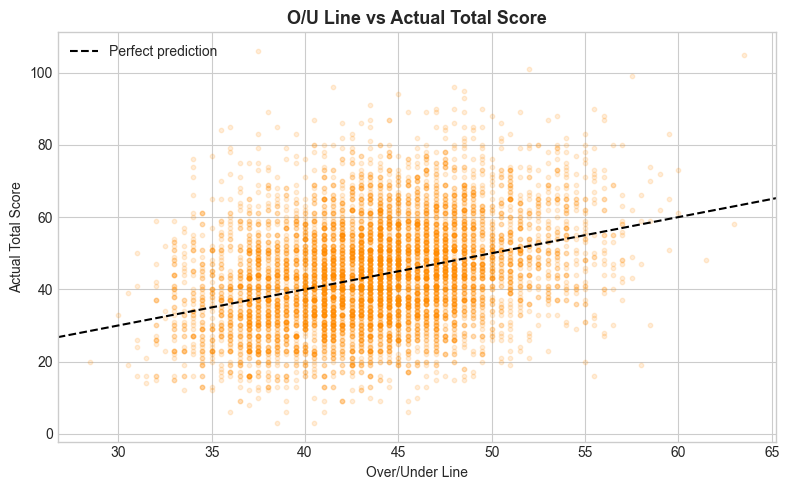

                mean  count
ou_bucket                  
<38 (low)   0.498058   1030
38-42       0.488930   1626
42-46       0.483871   2201
46-50       0.470388   1469
50+ (high)  0.475894    643


In [75]:
df_modern['total_score'] = df_modern['score_home'] + df_modern['score_away']
df_modern['went_over'] = (df_modern['total_score'] > df_modern['over_under_line']).astype(int)

over_rate = df_modern['went_over'].mean()
print(f"Over rate: {over_rate:.3f} ({over_rate*100:.1f}%)")

# O/U line vs actual total
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df_modern['over_under_line'], df_modern['total_score'], alpha=0.15, color='darkorange', s=10)
ax.axline((40, 40), slope=1, color='black', linestyle='--', linewidth=1.5, label='Perfect prediction')
ax.set_title('O/U Line vs Actual Total Score', fontsize=13, fontweight='bold')
ax.set_xlabel('Over/Under Line')
ax.set_ylabel('Actual Total Score')
ax.legend()
plt.tight_layout()
plt.savefig('fig4_over_under.png', dpi=150, bbox_inches='tight')
plt.show()

# Over rate by O/U bucket
df_modern['ou_bucket'] = pd.cut(df_modern['over_under_line'], bins=[30,38,42,46,50,65],
    labels=['<38 (low)', '38-42', '42-46', '46-50', '50+ (high)'])
print(df_modern.groupby('ou_bucket', observed=True)['went_over'].agg(['mean','count']))

In [77]:
division_map = {
    # AFC East
    'new england patriots': 'AFC East',
    'buffalo bills': 'AFC East',
    'miami dolphins': 'AFC East',
    'new york jets': 'AFC East',

    # AFC North
    'baltimore ravens': 'AFC North',
    'pittsburgh steelers': 'AFC North',
    'cleveland browns': 'AFC North',
    'cincinnati bengals': 'AFC North',

    # AFC South
    'houston texans': 'AFC South',
    'indianapolis colts': 'AFC South',
    'jacksonville jaguars': 'AFC South',
    'tennessee titans': 'AFC South',

    # AFC West
    'kansas city chiefs': 'AFC West',
    'las vegas raiders': 'AFC West',
    'oakland raiders': 'AFC West',
    'san diego chargers': 'AFC West',
    'los angeles chargers': 'AFC West',
    'denver broncos': 'AFC West',

    # NFC East
    'dallas cowboys': 'NFC East',
    'new york giants': 'NFC East',
    'philadelphia eagles': 'NFC East',
    'washington redskins': 'NFC East',
    'washington football team': 'NFC East',
    'washington commanders': 'NFC East',

    # NFC North
    'chicago bears': 'NFC North',
    'detroit lions': 'NFC North',
    'green bay packers': 'NFC North',
    'minnesota vikings': 'NFC North',

    # NFC South
    'atlanta falcons': 'NFC South',
    'carolina panthers': 'NFC South',
    'new orleans saints': 'NFC South',
    'tampa bay buccaneers': 'NFC South',

    # NFC West
    'arizona cardinals': 'NFC West',
    'los angeles rams': 'NFC West',
    'st. louis rams': 'NFC West',
    'san francisco 49ers': 'NFC West',
    'seattle seahawks': 'NFC West',
}

# Map both teams to their division
df_modern['home_division'] = df_modern['team_home'].map(division_map)
df_modern['away_division'] = df_modern['team_away'].map(division_map)

# Flag division games
df_modern['is_division_game'] = (
    df_modern['home_division'] == df_modern['away_division']
).astype(int)

In [78]:
print(df_modern['is_division_game'].value_counts())
print(f"\nSample division games:")
print(df_modern[df_modern['is_division_game'] == 1][['team_home','team_away','home_division']].head(5))

is_division_game
0    4502
1    2469
Name: count, dtype: int64

Sample division games:
                team_home            team_away home_division
7357       dallas cowboys  philadelphia eagles      NFC East
7361    minnesota vikings        chicago bears     NFC North
7365      oakland raiders   san diego chargers      AFC West
7366  pittsburgh steelers     baltimore ravens     AFC North
7372   cincinnati bengals     cleveland browns     AFC North


In [79]:
#conference map
conference_map = {
    'AFC East': 'AFC',
    'AFC North': 'AFC',
    'AFC South': 'AFC',
    'AFC West': 'AFC',
    'NFC East': 'NFC',
    'NFC North': 'NFC',
    'NFC South': 'NFC',
    'NFC West': 'NFC'
}
df_modern['home_conference'] = df_modern['home_division'].map(conference_map)
df_modern['away_conference'] = df_modern['away_division'].map(conference_map)

df_modern['is_conference_game'] = (
    df_modern['home_conference'] == df_modern['away_conference']
).astype(int)

In [80]:
print(df_modern['is_conference_game'].value_counts())
print(f"\nSample conference games:")
print(df_modern[df_modern['is_conference_game'] == 1][['team_home','team_away','home_conference']].head(5))

is_conference_game
1    5207
0    1764
Name: count, dtype: int64

Sample conference games:
               team_home             team_away home_conference
7354     atlanta falcons   san francisco 49ers             NFC
7355       buffalo bills      tennessee titans             AFC
7356    cleveland browns  jacksonville jaguars             AFC
7357      dallas cowboys   philadelphia eagles             NFC
7359  kansas city chiefs    indianapolis colts             AFC


## 4. Predictive Modeling

In [84]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

features = ['spread_magnitude', 'home_favorite', 'over_under_line', 'is_playoff', 'weather_wind_mph', 'is_division_game' ]
target = 'favorite_cover'

model_df = df_modern[features + [target]].dropna()
X = model_df[features]
y = model_df[target]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Logistic Regression — interpretable baseline
lr = LogisticRegression(random_state=42)
lr_scores = cross_val_score(lr, X_scaled, y, cv=5, scoring='accuracy')
print(f"Logistic Regression CV Accuracy: {lr_scores.mean():.4f} ± {lr_scores.std():.4f}")

# Random Forest — captures non-linearities
rf = RandomForestClassifier(n_estimators=200, max_depth=4, random_state=42)
rf_scores = cross_val_score(rf, X, y, cv=5, scoring='accuracy')
print(f"Random Forest CV Accuracy:      {rf_scores.mean():.4f} ± {rf_scores.std():.4f}")

print("\n--- Interpretation Note ---")
print("Accuracy near 50% is EXPECTED in an efficient market.")
print("The interesting findings are in WHICH factors carry the most signal.")

Logistic Regression CV Accuracy: 0.5295 ± 0.0011
Random Forest CV Accuracy:      0.5278 ± 0.0083

--- Interpretation Note ---
Accuracy near 50% is EXPECTED in an efficient market.
The interesting findings are in WHICH factors carry the most signal.


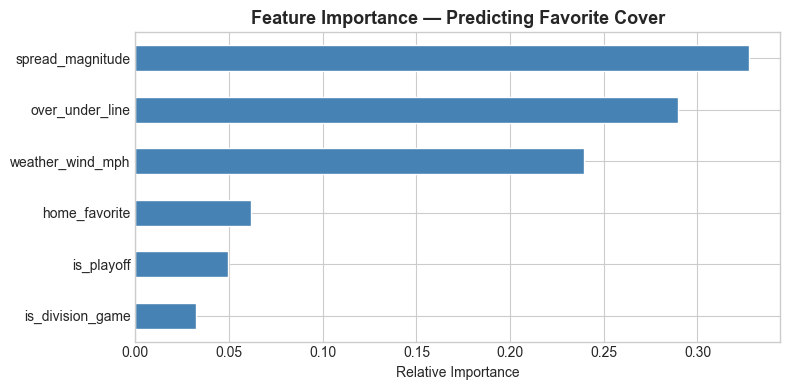


Logistic Regression Coefficients (direction of effect):
            feature  coefficient
0  spread_magnitude    -0.044728
3        is_playoff    -0.020843
5  is_division_game    -0.009804
4  weather_wind_mph     0.012744
2   over_under_line     0.014112
1     home_favorite     0.030721


In [85]:
# Feature importance from Random Forest
rf.fit(X, y)
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
importances.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Feature Importance — Predicting Favorite Cover', fontsize=13, fontweight='bold')
ax.set_xlabel('Relative Importance')
plt.tight_layout()
plt.savefig('fig5_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Logistic regression coefficients (directional signals)
lr.fit(X_scaled, y)
coef_df = pd.DataFrame({'feature': features, 'coefficient': lr.coef_[0]}).sort_values('coefficient')
print("\nLogistic Regression Coefficients (direction of effect):")
print(coef_df)

## 5. Summary & Market Efficiency Conclusions

### Data Preparation

When first looking at our dataset, I found that there were games from 1966 to 2025. I decided to just look at the modern era, after 2000, since betting markets and the NFL has changed so much. This left us with about 7000 games. When trying to calculate the margin and if the favorite covered the spread, I found that the favorite was listed in the dataset as just a 3 letter abbreviation, instead of the full team name. This was going to be an issue, so I had to create a dictionary to map the 3 letter team abbreviation to the full name. During this process, I found that there were 46 games that were pick’ems, meaning they were true coin flip games, or a game with no favorite (point spread = 0). I decided since this was less than 1% of the data, I would just drop these rows. When mapping the 3 letter abbreviation to the team name, I had to be careful because of teams that changed names or cities. For example, Washington went from the Redskins, to the football team, to the current name, the Commanders. The Chargers moved from San Diego to LA. Once this mapping was done, I was able to get the underdog and favorite scores. Then, I could find the margin of the game and mark if the favorite covered or not. During the feature engineering process, I created several new features to be used for analysis and in the model. home_favorite was created to mark if the favorite had home field advantage. spread_magnitude is the absolute value of the spread. This is done to see if larger favorites covered more often, field goal favorites covered less, etc. is_playoff was created where 0 is a regular season game and 1 is a playoff game. A feature called total_score was created to calculate the total score of the game. over_line is a binary feature that determines if the actual score of the game went over the over/under line in the game. 

### Exploratory Data Analysis

After creating these new features we had 6971 games, with favorites covering the spread 46.9% of the time and the game going over the O/U line 48.4% of the time. When looking at the distribution of the spread, we see the largest spike at -3. This is the field goal line, which is the most common margin in football. Sportsbooks cluster spreads at this line because it’s the most likely outcome. We see another spike at -7, which makes sense, since this is a touchdown line. In another visualization, I analyzed the spread vs. the actual margin in the game. In most games, I found favorites won by less than expected, or the underdog covered. This makes sense since I found that favorites cover 46.9% of the time. The market slightly overvalues favorites. This is where “fade the public” comes into play. Casual bettors will put lots of money on the favorites, so books will move the line to compensate. In turn, the favorites end up slightly overpriced. Our 46.9% cover rate by favorites suggests a historical bias towards the underdog. However, this edge is too small to exploit. This is true for a few reasons:
1. The vig, or “juice”, will catch up to you and you won’t be profitable over time. This is the “fee” built into sports betting, so they make profit regardless of the outcome. On standard spread bets, you have to bet $110 to win $100 (-110) odds. Therefore, you can’t just win over 50% of bets to win money. You need to be right 52.4% of the time to break even. Our underdog cover rate is only 53.1%, a super small edge. 
2. The market will adjust. When sharp money consistently bets the underdogs, the books will move the line to make up for this. This edge could already be gone by the time you go to place the bet. 
3. In this analysis, there is no opening lines. We want to be able to see if you beat where the line closed at not just the final spread. Someone that consistently beats the closing line has an edge. This dataset only had one number for the spread, so we don’t really know if this is the opening or closing line. 
The key is to be able to find when a line is misplaced in real time.

When analyzing the over/under line I had some interesting findings. When viewing the O/U line vs the actual total score, our data is more symmetrically centered around the prediction line compared to the spread scatter plot. This market may be more efficient than the spread market. Over time, the line fluctuates between there being an over or under bias from year to year. The value in 2025 is the closest it’s been to 50%, which shows the market is correcting for the bias as time goes on. The edge seems to be shrinking as time progresses. For most years, the under bias is strong, meaning history suggests it was smart to bet the under. This makes sense, as the public tends to bet the over because casual bettors tend to want to root for higher scoring games. The market seems to be adjusting to this, though. When viewing if wind had an impact on the over/under, I found that non-windy conditions suggest that the over tends to hit more often. Anything more than 5 MPH winds, the under tends to hit more often. This makes sense, as the windier it gets, the more difficult it is for teams to score. One important thing to note: sample sizes drop off hard as wind speeds increase. There were almost 3000 games with 0-5 MPH winds, but only 254 games with 16-20 MPH winds and 69 games with 20+ MPH. So, because of the smaller sample sizes, this may not actually be a market we can exploit after vig and market correction. 

I found that the cover rate of 46.9% is statistically significant with the p-value < 0.0001. This confirms an underdog bias in the NFL from 2000-2025. However, it is insufficient to create positive expected value after juice (-110). The market is efficient despite the bias. This reflects the public money overvaluing favorites.

### Modeling

I wanted to select certain features to use in my model to try to predict if the favorite will cover or not. These are the features I chose to use in my model:
- spread_magnitude: This shows how big the favorite is in the game. The market is telling us whether they think the game is competitive (slight favorites of -1.5) or a blowout (large favorites of -14). This could have an impact on if the favorite covers or not.
- home_favorite: A favorite playing at home is a way different situation than a favorite playing on the road. 
- over_under_line: This total tells us what the market believes will be the style and pace of the game. High-scoring games could affect the spread differently than defensive games.
- is_playoff: Playoff games tend to be closer, more competitive games. This will be used to see if our favorites will cover less in playoff games or not.
- weather_wind_mph: I found that the wind will slow down scoring, so this could potentially affect whether to not the favorite covers. 
- is_division_game: Divisional opponents play each other twice a year, so they tend to know each other’s tendencies and personnel better. These games tend to be closer which could impact the spread.

I did not include total_score or over_line in the model because of target leakage. Both these are determined by the final score of the game, something that isn’t known until the end of the game, or after the bet is already placed. If the model learns off these features, it will struggle in practice because it won’t have this information when it actually needs to make a decision.

After running Logistic Regression and Random Forest models, I found an overall accuracy of 52.9% and 52.8%, respectively. There is some predictability, but it’s right at the break even point of 52.4%, meaning there isn’t an edge to exploit. The spread magnitude had the largest negative predictor in the Logistic Regression model. The larger that the spread is, the less likely the favorite is to cover. This goes back to our finding of a 46.9% cover rate; the market overvalues large favorites. In the Logistic Regression model, home_favorite was the strongest positive predictor, which means home favorites cover more often than road favorites. in_playoff and is_division_game were negative predictors, proving that playoff and division games are closer and more competitive, making it harder for the favorites to cover the spread. In the Random Forest model, the spread_magnitude, over_under_line, and weather_wind_mph dominate the importance scores, which makes sense considering random forest inflate continuous features over binary ones. 

### Limitations

One major limitation with the data is that we don’t have opening and closing lines. Therefore, we can’t measure the true closing line value. There also isn’t any in-game data. Some more useful data that could improve our model would be injuries. Key injuries can have a huge impact on favorites covering the spread or not. Travel and rest days are additional data that could also improve the model.